#AQFT - comparativo entre AQFT e valor esperado QFT

In [2]:
"""
to prepare the environment
1. create a virtual environment: 
    python -m venv ./venv
2. upgrade pip: 
    python -m pip install --upgrade pip
3. install libraries:
## installing NumPy and MatPlotLib
    pip install numpy
    pip install matplotlib
## installing PyCryptodome
    pip install pycryptodome
## installing Qiskit
    pip install qiskit
    pip install qiskit-aer
    pip install qiskit-ibm-runtime
    pip install pylatexenc
"""
## carrega bibliotecas
import qiskit
import Crypto
import decimal

from decimal import *

from datetime import datetime
from Crypto.Util import number
from Crypto.Random import random
import matplotlib.pyplot as plt
import numpy as np
import math

from fractions import Fraction

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector


print(qiskit.__version__)
print(np.__version__)
print(decimal.__version__)
print(Crypto.__version__)


2.3.1
2.3.4
1.70
3.23.0


# gera a AQFT - gerado com auxilio do Anthropic Claude

In [ ]:
#### aplica o shor para fatorar um número composto N usando a base a
def return_order(N: int, a: int) -> int:
    r = 1
    power = a % N
    while power != 1 and r <= N:
        power = (power * a) % N
        r += 1
    return r

def shors_algorithm(N: int ) -> int:
    """Implementação simplificada do algoritmo de Shor para fatoração de N usando a base a."""
    MAX_TENTATIVAS = N
    tentativas = 0

    while tentativas < MAX_TENTATIVAS:
        tentativas += 1
        # Passo 1: Seleciona um a aleatório entre 2 e N-1 e coprimo com N
        a = random.randint(2, N - 1)
        print(f"Tentativa {tentativas}: a = {a}")
        if math.gcd(a, N) != 1:
            print(f"{a} não é coprimo com {N}. Encontrado fator trivial: {math.gcd(a, N)}")
            continue
        
        # Passo 2: Encontrar a ordem r de a módulo N
        r = return_order(N, a)
        if r % 2 != 0:
            print(f"A ordem r = {r} é ímpar. Tentando outro valor de a.")
    
        ar_half = pow(a, r // 2, N)
        if ar_half == N - 1:
            print(f"a^(r/2) é congruente a -1 mod N. Tente outro valor de a.")
            continue
        
        # Passo 4: Calcular os fatores candidatos
        factor1 = math.gcd(ar_half - 1, N)
        factor2 = math.gcd(ar_half + 1, N)
        
        # Verificar se os fatores são válidos
        if factor1 in [1, N] or factor2 in [1, N]:
            print(f"Fatores triviais encontrados. Tente outro valor de a.")
            continue
        
        return factor1, factor2, a, r
    print(f"Falha ao encontrar fatores não triviais após {MAX_TENTATIVAS} tentativas.")
    

def find_shor_example(nBits=16):
    # Gerar um número composto N para fatorar
    p = number.getPrime(nBits // 2)
    q = number.getPrime(nBits // 2 + nBits % 2)
    N = p * q
    print(f"N = {N} (fatores: {p}, {q})")
    
    # Executar o algoritmo de Shor
    factor1, factor2, a, r = shors_algorithm(N)
    if factor1 is not None:
        print(f"N={N}, a={a}, r={r}, p={factor1}, q={factor2}")  
    else:
        print("Nenhum fator encontrado.")

find_shor_example(nBits=20)
# exemplos
# 16 bits
# N=29737, a=9094, r=14690, p=131, q=227
# N=34717, a=29699, r=8584, p=149, q=233
# N=27221, a=4888, r=13446, p=163, q=167
# N=60491, a=44565, r=120, p=251, q=241
# N=32437, a=23138, r=594, p=163, q=199
# N=21509, a=15983, r=5304, p=157, q=137
# N=26123, a=10452, r=516, p=151, q=173
# N=45901, a=12354, r=11368, p=197, q=233
# N=33389, a=28255, r=8256, p=173, q=193
# N=41693, a=10464, r=3440, p=173, q=241
#
# 5 bits
# N=35, a=32, r=12, p=7, q=5
# N=21, a=11, r=6, p=7, q=3
# N=15, a=8, r=4, p=3, q=5
#
# 20 bits
# N=525323, a=235635, r=130962, p=599, q=877

N = 525323 (fatores: 877, 599)
Tentativa 1: a = 235635
N=525323, a=235635, r=130962, p=599, q=877


Exemplo: N=21, a=11, r=6, p=7, q=3, L=5, phi=2*pi*0.3333333333333333
Circuito AQFT† - L=5, m=4:
Statevector([ 1.76776695e-01+0.00000000e+00j,
             -2.31296463e-18+4.62592927e-18j,
              1.85037171e-17+9.25185854e-18j,
              0.00000000e+00+1.08244507e-17j,
             -4.62592927e-17+2.77555756e-17j,
             -9.25185854e-18+9.25185854e-17j,
              1.76776695e-01-1.08244507e-16j,
             -2.77555756e-17+6.47630098e-17j,
              8.78926561e-17+5.55111512e-17j,
              0.00000000e+00-7.21994785e-17j,
             -1.91976065e-16+8.32667268e-17j,
             -6.93889390e-17+2.82181685e-16j,
              1.76776695e-01-2.16489014e-16j,
             -7.63278329e-17+5.08852220e-17j,
              7.86407976e-17+7.86407976e-17j,
              0.00000000e+00-2.07559823e-16j,
             -1.78098277e-16+1.15648232e-16j,
              9.25185854e-18+2.03540888e-16j,
              1.76776695e-01-1.15387860e-16j,
              6.01370805e-17+3

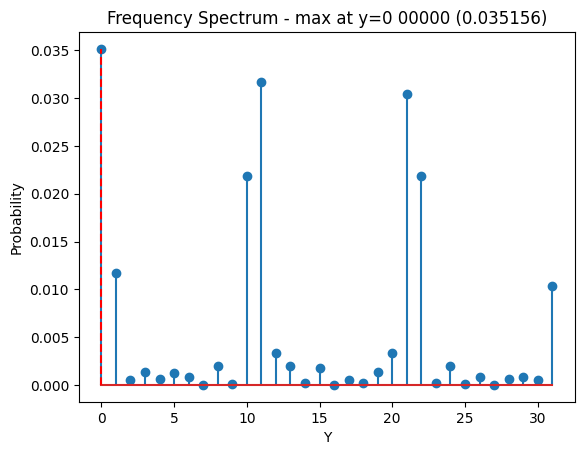

Circuito AQFT† - L=5, m=3:
Statevector([ 1.76776695e-01+0.00000000e+00j,
             -2.31296463e-18+4.62592927e-18j,
              1.85037171e-17+9.25185854e-18j,
              0.00000000e+00+1.08244507e-17j,
             -4.62592927e-17+2.77555756e-17j,
             -9.25185854e-18+9.25185854e-17j,
              1.76776695e-01-1.08244507e-16j,
             -2.77555756e-17+6.47630098e-17j,
              8.78926561e-17+5.55111512e-17j,
              0.00000000e+00-7.21994785e-17j,
             -1.91976065e-16+8.32667268e-17j,
             -6.93889390e-17+2.82181685e-16j,
              1.76776695e-01-2.16489014e-16j,
             -7.63278329e-17+5.08852220e-17j,
              7.86407976e-17+7.86407976e-17j,
              0.00000000e+00-2.07559823e-16j,
             -1.78098277e-16+1.15648232e-16j,
              9.25185854e-18+2.03540888e-16j,
              1.76776695e-01-1.15387860e-16j,
              6.01370805e-17+3.83952129e-16j,
              3.79326200e-16+1.75785312e-16j,
       

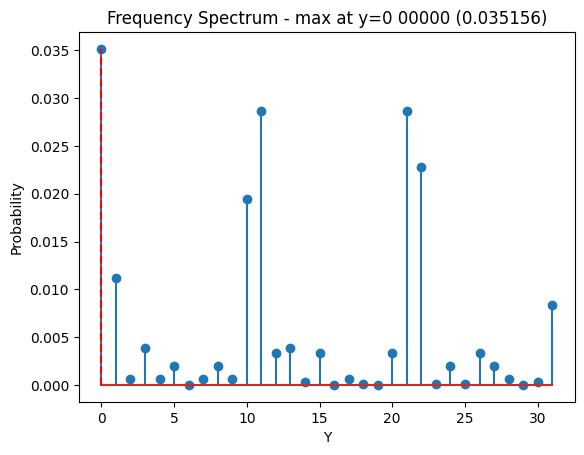

In [19]:
def aqft_dagger(L: int, m: int) -> QuantumCircuit:
    """
    AQFT inversa truncada em L qubits.
    Mantém apenas rotações controladas até distância m.
    Para m >= L, coincide com a IQFT usual (sem swaps explícitos, mas com
    correção de bit-reversal na leitura).
    """
    qc = QuantumCircuit(L, name=f"AQFT†(L={L},m={m})")
    # Implementação padrão da IQFT sem swaps finais
    for j in range(L):
        # rotações controladas truncadas
        start_k = max(0, j - m + 1)
        for k in range(start_k, j):
            angle = -np.pi / (2 ** (j - k))
            qc.cp(angle, k, j)
        qc.h(j)
    return qc


def define_initial_state_for_order(r: int, L: int ) -> Statevector:
    """
    Estado do registrador de fase após phase kickback e antes da IQFT/AQFT:
    (1/sqrt(2^L)) sum_x exp(2πi phi x) |x>
    """
    M = 2 ** L
    #r=M//r
    amps = np.zeros(M, dtype=complex)
    for i in range(r):
        phi = i/r
        amps += np.exp(2j * np.pi * phi * np.arange(M)) / np.sqrt(M)
    amps /= r  # Normaliza o vetor de estado
    #phi = 1/r
    #amps += np.exp(2j * np.pi * phi * np.arange(M)) / np.sqrt(M)
    return Statevector(amps)

def define_initial_state_for_phase_estimation(phi: float, L: int ) -> Statevector:
    """
    Estado do registrador de fase após phase kickback e antes da IQFT/AQFT:
    (1/sqrt(2^L)) sum_x exp(2πi phi x) |x>
    """
    M = 2 ** L
    amps = np.exp(2j * np.pi * phi * np.arange(M)) / np.sqrt(M)
    return Statevector(amps)

def bit_reverse(x: int, nbits: int) -> int:
    out = 0
    for _ in range(nbits):
        out = (out << 1) | (x & 1)
        x >>= 1
    return out

def aqft_example(N, a, r, p, q):
    L = int(math.log2(N))+1
    phi = ((r-4)/r)
        
    # gera AQFT† para diferentes m
    print(f"Exemplo: N={N}, a={a}, r={r}, p={p}, q={q}, L={L}, phi=2*pi*{phi:.16f}")
    for m in [L-1,3]:
        qc = aqft_dagger(L, m)
        print (f'Circuito AQFT† - L={L}, m={m}:')
        fig = qc.draw('mpl')
        fig.suptitle(f'AQFT† - L={L}, m={m}', fontsize=16)
        fig.savefig(f'img/aqft_dagger_L_{L}_m_{m}.png')

        #sv_initial = define_initial_state_for_phase_estimation(phi, L)
        sv_initial = define_initial_state_for_order(r, L)
        print(f'{sv_initial}')

        sv_final = sv_initial.evolve(qc)
        print(f'{sv_final}')

        probs = sv_final.probabilities()
        reordered_probs = np.zeros_like(probs)
        for y, p in enumerate(probs):
            reordered_probs[bit_reverse(y, L)] = p
    
        ys = np.arange(len(probs))
        peak_y = np.argmax(probs)
        peak_value = np.max(probs)

        plt.figure()
        plt.stem(ys, probs)
        plt.xlabel("Y")
        plt.ylabel("Probability")
        plt.title(f"Frequency Spectrum - max at y={peak_y} {peak_y:0{L}b} ({peak_value:.6f})")
        plt.vlines(peak_y, 0, peak_value,colors='r', linestyles='dashed', label='Peak')
        plt.show()
        
    return

#aqft_example(N=15, a=8, r=4, p=3, q=5)
aqft_example(N=21, a=11, r=6, p=7, q=3)
#aqft_example(N=34717, a=29699, r=8584, p=149, q=233)